In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
from gbeampro import GaussBeam, Propagation, ThinLens, Interface, InterfaceCurved, OpticalSystem
import gbeampro.plot as gplot
import gbeampro.analysis as ga
import gbeampro
print('gbeampro version:', gbeampro.__version__)

gbeampro version: 2.0.0


## Case 1: ThinLens による集光

In [2]:
beam1 = GaussBeam.from_waist(wl_um=1.064, w0_mm=1.0)
sys1 = (OpticalSystem()
        .add(Propagation(100))
        .add(ThinLens(50))
        .add(Propagation(100)))

print(sys1)
print()
print(sys1.summary(beam1))

OpticalSystem
   #  Type                Parameters                z (mm)
---------------------------------------------------------
   0  --- input ---                                  0.000
   1  Propagation         d =  100.000 mm          100.000
   2  ThinLens            f =   50.000 mm          100.000
   3  Propagation         d =  100.000 mm          200.000
Total length: 200.000 mm  |  3 elements

OpticalSystem trace  [wl=1.064 um]
   #  Type                   z (mm)     w (um)      R (mm)   th (urad)
------------------------------------------------------------------------
   0  --- input ---           0.000    1000.00         inf      338.68
   1  Propagation           100.000    1000.57   8.728e+04      338.49
   2  ThinLens              100.000    1000.57  -5.003e+01      338.49
   3  Propagation           200.000    1000.00   5.000e+01      338.68
Beam waists:  z=150.020 mm (2w0=33.9 um)


In [3]:
beam2 = GaussBeam.from_waist(wl_um=0.532, w0_mm=0.6)

print(sys1.summary(beam2))

OpticalSystem trace  [wl=0.532 um]
   #  Type                   z (mm)     w (um)      R (mm)   th (urad)
------------------------------------------------------------------------
   0  --- input ---           0.000     600.00         inf      282.23
   1  Propagation           100.000     600.66   4.529e+04      281.92
   2  ThinLens              100.000     600.66  -5.006e+01      281.92
   3  Propagation           200.000     600.00   5.000e+01      282.23
Beam waists:  z=150.030 mm (2w0=28.2 um)


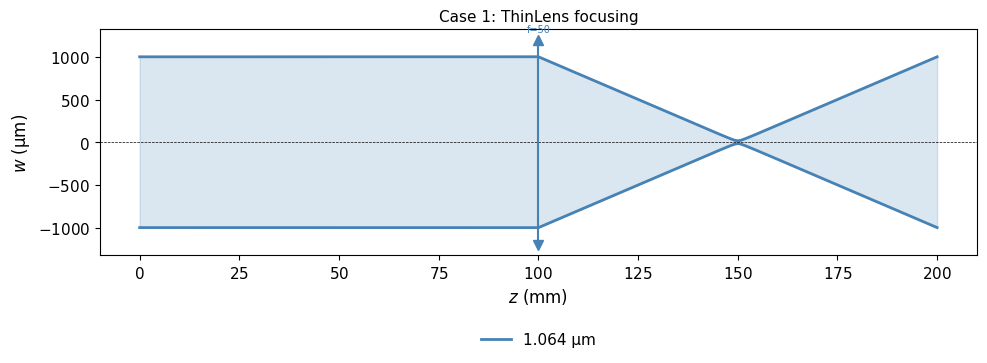

In [4]:
traj1 = sys1.trace(beam1, dz=0.5)

fig, ax = plt.subplots(figsize=(10, 4))
gplot.plot_system(sys1, traj1, ax, label='1.064 µm', beam_kw={'color': 'steelblue'})

ax.set_title('Case 1: ThinLens focusing')
plt.tight_layout()

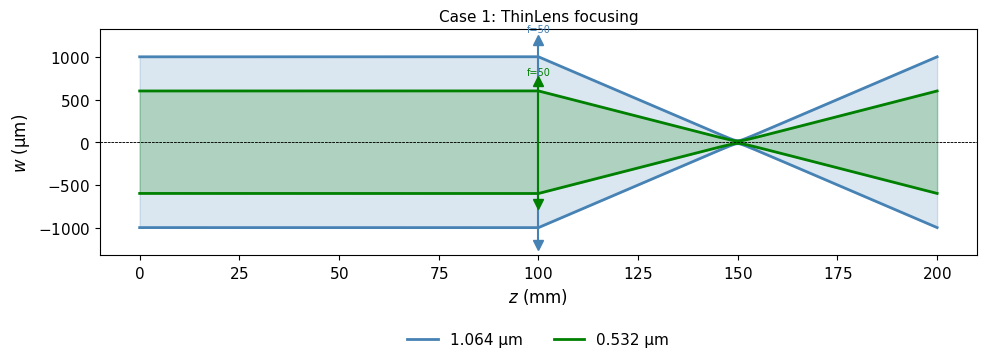

In [5]:
traj2 = sys1.trace(beam2, dz=0.5)
gplot.plot_system(sys1, traj2, ax, label='0.532 µm', beam_kw={'color': 'green'})
fig

## Case 2: 結晶への集光（Interface あり）

In [6]:
n_crystal = 1.60
beam2 = GaussBeam.from_waist(wl_um=1.064, w0_mm=1.5)
sys2 = (OpticalSystem()
        .add(Propagation(150))
        .add(ThinLens(150))
        .add(Propagation(140))
        .add(Interface(1.0, n_crystal))
        .add(Propagation(20))
        .add(Interface(n_crystal, 1.0))
        .add(Propagation(190))
        .add(ThinLens(200))
        .add(Propagation(100)))

print(sys2)

OpticalSystem
   #  Type                Parameters                z (mm)
---------------------------------------------------------
   0  --- input ---                                  0.000
   1  Propagation         d =  150.000 mm          150.000
   2  ThinLens            f =  150.000 mm          150.000
   3  Propagation         d =  140.000 mm          290.000
   4  Interface           n 1.0000 -> 1.6000       290.000
   5  Propagation         d =   20.000 mm          310.000
   6  Interface           n 1.6000 -> 1.0000       310.000
   7  Propagation         d =  190.000 mm          500.000
   8  ThinLens            f =  200.000 mm          500.000
   9  Propagation         d =  100.000 mm          600.000
Total length: 600.000 mm  |  9 elements


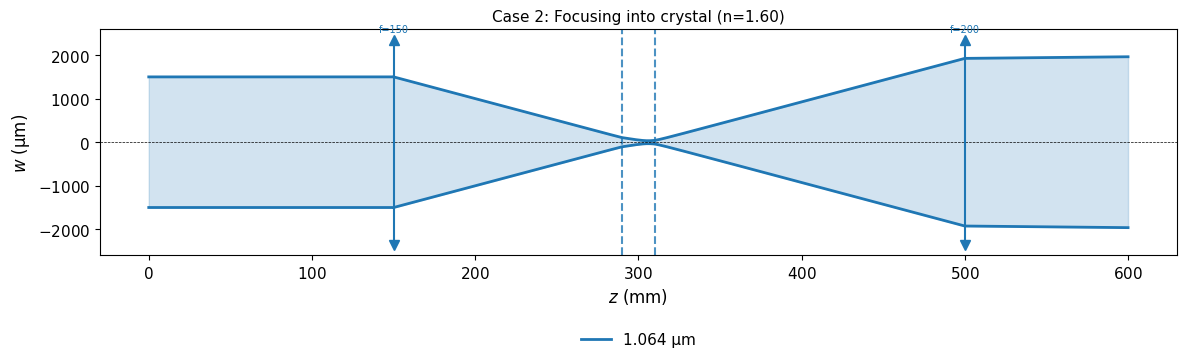

In [7]:
traj2 = sys2.trace(beam2, dz=0.5)

fig, ax = plt.subplots(figsize=(12, 4))
gplot.plot_system(sys2, traj2, ax, label='1.064 µm')
ax.set_title('Case 2: Focusing into crystal (n=1.60)')
plt.tight_layout()

In [8]:
print(sys2.summary(beam2))

OpticalSystem trace  [wl=1.064 um]
   #  Type                   z (mm)     w (um)      R (mm)   th (urad)
------------------------------------------------------------------------
   0  --- input ---           0.000    1500.00         inf      225.79
   1  Propagation           150.000    1500.38   2.944e+05      225.73
   2  ThinLens              150.000    1500.38  -1.501e+02      225.73
   3  Propagation           290.000     105.58  -1.115e+01     3207.82
   4  Interface             290.000     105.58  -1.784e+01     2004.89
   5  Propagation           310.000      42.10   1.134e+01     5028.40
   6  Interface             310.000      42.10   7.088e+00     8045.33
   7  Propagation           500.000    1925.30   1.926e+02      175.91
   8  ThinLens              500.000    1925.30   5.176e+03      175.91
   9  Propagation           600.000    1962.57   5.254e+03      172.57
Beam waists:  z=306.000 mm (2w0=67.7 um)


## Case 3: analysis 関数の確認

In [9]:
waists = ga.find_waists(traj2)
for w in waists:
    print(f'z={w.z_mm:.2f} mm  2w0={w.w_mm*2e3:.1f} µm  '
          f'z_R={ga.rayleigh_range(w):.2f} mm  2z_R={ga.confocal_parameter(w):.2f} mm')

z=306.00 mm  2w0=67.7 µm  z_R=5.42 mm  2z_R=10.84 mm
